# 🤖 5. ResNet full preprocessing models — with Dropout

**Deep learning models for retinal fundus image classification and SE regression**

The purpose of this notebook is to evaluate a deeper custom ResNet architecture on the fully preprocessed retinal fundus images, for both binary myopia classification and continuous SE regression.

This notebook is especially useful as a comparison against the previous small CNN notebooks. The key question is whether increasing architectural complexity improves performance, or whether the main limitation comes from the dataset, the preprocessing pipeline and the weak image-to-SE signal.


## ⚙️ 1. Setting up

Create a deterministic Train/Val/Test split (satrtified)

Building a DataFrame with image paths and labels. Splitting the dataset into train, validation, and test sets (80/10/10) with stratification to keep class balance (avoids bias if one class bigger than the other).

In [1]:
from pathlib import Path
import sys
import importlib
import pandas as pd
# from sklearn.model_selection import train_test_split - importing splits now
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers
import numpy as np
import matplotlib.pyplot as plt
import os, random

# Load configurable project paths ============================================================

# Project root detection
PROJECT_ROOT = Path.cwd().resolve()

while not (PROJECT_ROOT / "config.yaml").exists():
    if PROJECT_ROOT == PROJECT_ROOT.parent:
        raise FileNotFoundError("config.yaml was not found. Make sure it is located in the project root.")
    PROJECT_ROOT = PROJECT_ROOT.parent

if str(PROJECT_ROOT) not in sys.path:
    sys.path.insert(0, str(PROJECT_ROOT))

importlib.invalidate_caches()

from src.paths import (
    load_config,
    get_paths,
    get_experiment_paths,
    validate_main_structure,
    validate_experiment_paths,
    print_paths
)

cfg = load_config(PROJECT_ROOT / "config.yaml")

paths = get_paths(cfg)
validate_main_structure(paths)

exp_paths = get_experiment_paths(cfg, "full_preproc")
validate_experiment_paths(exp_paths)

# General settings ===========================================================

SEED = int(cfg["settings"]["seed"])
IMG_SIZE = tuple(cfg["settings"]["image_size"]) #from config.yaml - must match the preprocessed size
BATCH = int(cfg["settings"]["batch_size"]) #from config.yaml - number of images preprocessed in each training step

# Paths ===========================================================

TABLE_PATH = exp_paths["table"]

SPLIT_DIR_CLASSF = exp_paths["split_classification"]
SPLIT_DIR_REGRSS = exp_paths["split_regression"]

MODELS_DIR_FULL = exp_paths["models_experiment"]
MODELS_DIR_FULL.mkdir(parents=True, exist_ok=True)

print("Project root:", PROJECT_ROOT)
print("Table path:", TABLE_PATH)
print("Classification splits:", SPLIT_DIR_CLASSF)
print("Regression splits:", SPLIT_DIR_REGRSS)
print("Models output:", MODELS_DIR_FULL)
print("IMG_SIZE:", IMG_SIZE)
print("BATCH:", BATCH)
print("SEED:", SEED)

df = pd.read_excel(TABLE_PATH)

Project root: C:\Users\paula\0B_TFGBiomed_Exe
Table path: C:\Users\paula\0B_TFGBiomed_Exe\Tables\MatchTables\Tabla_MatchImagenesConDatosClinicos_FullPreproc.xlsx
Classification splits: C:\Users\paula\0B_TFGBiomed_Exe\Splits\Classification\FullPreproc
Regression splits: C:\Users\paula\0B_TFGBiomed_Exe\Splits\Regression\FullPreproc
Models output: C:\Users\paula\0B_TFGBiomed_Exe\ModelsToSave\WithDropout\FullPreproc
IMG_SIZE: (224, 224)
BATCH: 32
SEED: 42


In [2]:
# Keep only images with valid path and existent SE targets
df = df[df["image_path"].notna()].copy()
df = df[df["target_SE"].notna()].copy()
df = df[df["class_label"].notna()].copy()

df["image_path"] = df["image_path"].astype(str)
df["patient_id"] = df["patient_id"].astype(str).str.upper().str.strip()
df["target_SE"] = pd.to_numeric(df["target_SE"], errors="coerce")
df["class_label"] = pd.to_numeric(df["class_label"], errors="coerce").astype("int32")

df = df.dropna(
    subset=["image_path", "filename", "patient_id", "target_SE", "class_label"]
).copy()

# Verify paths exist before training
missing_paths = df["image_path"].apply(lambda p: not Path(p).exists()).sum()
print("Missing image paths:", missing_paths)

assert missing_paths == 0, "Some image paths do not exist. Check the FullPreproc match table."

Missing image paths: 0


In [3]:
df["class_label"] = df["class_label"].astype("int32")
print("Total valid images (with SE):", len(df))
print("\nClassification label balance (0 = non-myopic, 1 = myopic)")
print(df["class_label"].value_counts())
print("\nTarget SE summary:")
print(df["target_SE"].describe())

Total valid images (with SE): 2126

Classification label balance (0 = non-myopic, 1 = myopic)
class_label
0    1645
1     481
Name: count, dtype: int64

Target SE summary:
count    2126.000000
mean        0.021696
std         2.109061
min       -20.375000
25%        -0.250000
50%         0.000000
75%         0.750000
max         9.000000
Name: target_SE, dtype: float64


Dataset and target distribution

The dataset contains **2,126 valid images** with available **SE** and binary myopia labels. The class distribution is clearly imbalanced: **1,645 normal images** and **481 myopic images**, meaning that normal cases represent approximately **77%** of the dataset and myopic cases approximately **23%**.

This imbalance is important for classification. A model that simply predicted all images as normal would already obtain an accuracy close to **0.77–0.78**, so accuracy alone is not a reliable performance indicator. AUC, Average Precision, Precision-Recall curves and the confusion matrix are more informative.

The SE distribution is also highly centred around **0 D**, with a median of **0 D**, a mean close to **0.02 D** and a standard deviation of approximately **2.11 D**. This explains why SE regression is difficult: a model can obtain a moderate MAE by predicting values near the centre of the distribution, without actually learning a useful image-to-SE relationship.

This is the same clinical dataset used in the previous notebooks, so changes in performance here should mainly be attributed to the architecture and training configuration rather than to a change in the underlying data.


#### 1.2. Train/Val/Test split

In [4]:
# Stratified 80/10/10 split from 00_CreatePatientLevelSplits_Classf_Regrss.ipynb
# Stratification is done using the classification label from the matches table to keep myopia/normal balance across splits
train_df_classf = pd.read_csv(SPLIT_DIR_CLASSF / "train.csv")
val_df_classf   = pd.read_csv(SPLIT_DIR_CLASSF / "val.csv")
test_df_classf  = pd.read_csv(SPLIT_DIR_CLASSF / "test.csv")

train_df_regrss = pd.read_csv(SPLIT_DIR_REGRSS / "train.csv")
val_df_regrss   = pd.read_csv(SPLIT_DIR_REGRSS / "val.csv")
test_df_regrss  = pd.read_csv(SPLIT_DIR_REGRSS / "test.csv")

print("Classification split sizes:")
print("Train:", len(train_df_classf))
print("Val:  ", len(val_df_classf))
print("Test: ", len(test_df_classf))

print("\nRegression split sizes:")
print("Train:", len(train_df_regrss))
print("Val:  ", len(val_df_regrss))
print("Test: ", len(test_df_regrss))


def check_no_overlap(train_df, val_df, test_df, column: str, name: str) -> None:
    train_values = set(train_df[column].astype(str))
    val_values   = set(val_df[column].astype(str))
    test_values  = set(test_df[column].astype(str))

    assert len(train_values & val_values) == 0, f"{name}: overlap between train and val"
    assert len(train_values & test_values) == 0, f"{name}: overlap between train and test"
    assert len(val_values & test_values) == 0, f"{name}: overlap between val and test"

    print(f"OK: no {name} overlap across train/val/test.")


check_no_overlap(train_df_classf, val_df_classf, test_df_classf, "patient_id", "classification patient")
check_no_overlap(train_df_regrss, val_df_regrss, test_df_regrss, "patient_id", "regression patient")

check_no_overlap(train_df_classf, val_df_classf, test_df_classf, "image_path", "classification image")
check_no_overlap(train_df_regrss, val_df_regrss, test_df_regrss, "image_path", "regression image")

print("\nClassification label balance:")
print("Train:")
print(train_df_classf["class_label"].value_counts(normalize=True))
print("Val:")
print(val_df_classf["class_label"].value_counts(normalize=True))
print("Test:")
print(test_df_classf["class_label"].value_counts(normalize=True))

print("\nRegression target SE summary:")
print("Train:")
print(train_df_regrss["target_SE"].describe())
print("Val:")
print(val_df_regrss["target_SE"].describe())
print("Test:")
print(test_df_regrss["target_SE"].describe())

Classification split sizes:
Train: 1701
Val:   211
Test:  214

Regression split sizes:
Train: 1700
Val:   209
Test:  217
OK: no classification patient overlap across train/val/test.
OK: no regression patient overlap across train/val/test.
OK: no classification image overlap across train/val/test.
OK: no regression image overlap across train/val/test.

Classification label balance:
Train:
class_label
0    0.771899
1    0.228101
Name: proportion, dtype: float64
Val:
class_label
0    0.781991
1    0.218009
Name: proportion, dtype: float64
Test:
class_label
0    0.780374
1    0.219626
Name: proportion, dtype: float64

Regression target SE summary:
Train:
count    1700.000000
mean        0.006029
std         2.173365
min       -20.375000
25%        -0.250000
50%         0.000000
75%         0.625000
max         7.750000
Name: target_SE, dtype: float64
Val:
count    209.000000
mean       0.069976
std        1.860834
min      -14.000000
25%       -0.375000
50%        0.000000
75%        0.750

The classification split contains **1,701 training images**, **211 validation images** and **214 test images**. The regression split contains **1,700 training images**, **209 validation images** and **217 test images**.

The checks confirm that there is **no patient overlap** and **no image overlap** between train, validation and test sets. This is essential because the dataset contains multiple retinal images per patient, and patient leakage would make the evaluation artificially optimistic.

The class proportions remain stable across the classification splits, so the train/validation/test division is appropriate for evaluating binary myopia classification. For regression, the SE distributions remain centred close to 0 D, reinforcing again that **R²** is especially important when interpreting the regression results.


#### 1.3. Building TF datasets

Now we move onto building efficient TensorFlow datasets (tf.data pipeline) from image paths and labels, applying decoding, resizing, batching, and lightweight data augmentations for training.

In [5]:
AUTOTUNE = tf.data.AUTOTUNE #allows for paralelism automation

def decode_img(path, y):
    img = tf.io.read_file(path) #reades pic as bytes
    img = tf.image.decode_jpeg(img, channels=3) # decodes jpg into RGB tensor
    img = tf.image.convert_image_dtype(img, tf.float32)  # converts to float [0,1]
    img = tf.image.resize(img, IMG_SIZE, method='bilinear') #rescales to 224x224
    return img, y #gives pic+corresponding label/target

# Lightweight augmentations
augment = tf.keras.Sequential([
    tf.keras.layers.RandomFlip("horizontal"), #hozt flip (imitates eye flip)
    tf.keras.layers.RandomRotation(0.02), #slight rotation
    tf.keras.layers.RandomZoom(0.05), #slight random zoom
])


In [6]:
def make_classification_ds(csv_path, training=False): #creating the TensorFlow dataset for binary classf
    df_split = pd.read_csv(csv_path)
    paths = df_split["image_path"].astype(str).values
    labels = df_split["class_label"].astype("float32").values
    ds = tf.data.Dataset.from_tensor_slices((paths, labels))
    ds = ds.map(lambda p, y: decode_img(p, y), num_parallel_calls=AUTOTUNE) #applies decode_img on each image
    if training: #if trainig, it shuffles and applies augmentations 
        ds = ds.shuffle(8192, seed=SEED, reshuffle_each_iteration=True)
        ds = ds.map(lambda x, y: (augment(x, training=True), y), num_parallel_calls=AUTOTUNE)  #(aumentos)
    ds = ds.batch(BATCH).prefetch(AUTOTUNE) #prefetching makes pipeline faster
    return ds

def make_regression_ds(csv_path, training=False): #creating the TensorFlow dataset for SE regrss
    df_split = pd.read_csv(csv_path)
    
    paths = df_split["image_path"].astype(str).values
    targets = df_split["target_SE"].astype("float32").values
    
    ds = tf.data.Dataset.from_tensor_slices((paths, targets))
    ds = ds.map(lambda p, y: decode_img(p, y), num_parallel_calls=AUTOTUNE) #applies decode_img on each image
    
    if training: #if trainig, it shuffles and applies augmentations 
        ds = ds.shuffle(8192, seed=SEED, reshuffle_each_iteration=True) 
        ds = ds.map(lambda x, y: (augment(x, training=True), y), num_parallel_calls=AUTOTUNE)  #(aumentos)
    ds = ds.batch(BATCH).prefetch(AUTOTUNE) #prefetching makes pipeline faster
    return ds

In [7]:
train_ds_classf = make_classification_ds(SPLIT_DIR_CLASSF / "train.csv", training=True) #shuffle + augmentations
val_ds_classf = make_classification_ds(SPLIT_DIR_CLASSF / "val.csv", training=False) #decode + bacthing (no augs)
test_ds_classf = make_classification_ds(SPLIT_DIR_CLASSF / "test.csv", training=False) #decode + batching (no augs)

train_ds_regrss = make_regression_ds(SPLIT_DIR_REGRSS / "train.csv", training=True) #shuffle + augmentations
val_ds_regrss = make_regression_ds(SPLIT_DIR_REGRSS / "val.csv", training=False) #decode + bacthing (no augs)
test_ds_regrss = make_regression_ds(SPLIT_DIR_REGRSS / "test.csv", training=False) #decode + batching (no augs)

## 🧩 2. The models

#### 🟢 2.1. First model: ResNet classification
Now, we define our first ResNet model for binary classification.

In [8]:
def residual_block(x, filters, stride=1, dropout=0.0):
    shortcut = x

    x = layers.Conv2D(filters, 3, strides=stride, padding="same", use_bias=False)(x)
    x = layers.BatchNormalization()(x)
    x = layers.Activation("relu")(x)

    x = layers.Conv2D(filters, 3, padding="same", use_bias=False)(x)
    x = layers.BatchNormalization()(x)

    if stride != 1 or shortcut.shape[-1] != filters:
        shortcut = layers.Conv2D(filters, 1, strides=stride, padding="same", use_bias=False)(shortcut)
        shortcut = layers.BatchNormalization()(shortcut)

    x = layers.Add()([x, shortcut])
    x = layers.Activation("relu")(x)

    if dropout > 0:
        x = layers.SpatialDropout2D(dropout)(x)

    return x

In [9]:
def build_small_resnet_backbone(inputs, dropout=0.15):
    x = layers.Conv2D(32, 7, strides=2, padding="same", use_bias=False)(inputs)
    x = layers.BatchNormalization()(x)
    x = layers.Activation("relu")(x)
    x = layers.MaxPooling2D(pool_size=3, strides=2, padding="same")(x)

    x = residual_block(x, 32, stride=1, dropout=dropout)
    x = residual_block(x, 32, stride=1, dropout=dropout)

    x = residual_block(x, 64, stride=2, dropout=dropout)
    x = residual_block(x, 64, stride=1, dropout=dropout)

    x = residual_block(x, 128, stride=2, dropout=dropout)
    x = residual_block(x, 128, stride=1, dropout=dropout)

    x = residual_block(x, 256, stride=2, dropout=dropout)
    x = residual_block(x, 256, stride=1, dropout=dropout)

    x = residual_block(x, 512, stride=2, dropout=dropout)
    x = residual_block(x, 512, stride=1, dropout=dropout)

    x = layers.GlobalAveragePooling2D()(x)
    x = layers.Dropout(0.4)(x)

    x = layers.Dense(256, activation="relu")(x)
    x = layers.Dropout(0.4)(x)

    #outputs = layers.Dense(1, activation="sigmoid")(x)

    #return keras.Model(inputs, outputs, name="SmallResNetFromScratch")

    return x

In [10]:
def build_small_resnet_classf(input_shape=(224, 224, 3), dropout=0.15):
    inputs = keras.Input(shape=input_shape)

    x = build_small_resnet_backbone(inputs, dropout=dropout)

    # Classification head: binary output
    outputs = layers.Dense(1, activation="sigmoid", name="class_output")(x)

    return keras.Model(inputs, outputs, name="small_resnet_classification")

def compile_small_resnet_classf(lr=1e-4):
    model = build_small_resnet_classf(input_shape=(*IMG_SIZE, 3))

    model.compile(
        optimizer=keras.optimizers.Adam(learning_rate=lr),
        loss="binary_crossentropy",
        metrics=[
            keras.metrics.BinaryAccuracy(name="accuracy"),
            keras.metrics.AUC(name="auc"),
            keras.metrics.Precision(name="precision"),
            keras.metrics.Recall(name="recall"),
        ]
    )

    return model

    
model_classf = compile_small_resnet_classf(lr=1e-4)

In [11]:
model_classf.summary()

Model: "small_resnet_classification"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                  ┃ Output Shape              ┃         Param # ┃ Connected to               ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━┩
│ input_layer_1 (InputLayer)    │ (None, 224, 224, 3)       │               0 │ -                          │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ conv2d (Conv2D)               │ (None, 112, 112, 32)      │           4,704 │ input_layer_1[0][0]        │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ batch_normalization           │ (None, 112, 112, 32)      │             128 │ conv2d[0][0]               │
│ (BatchNormalization)          │                           │                 │                            │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ activation (Activation)       │ (None, 112, 112, 32)      │               0 │ batch_normalization[0][0]  │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ max_pooling2d (MaxPooling2D)  │ (None, 56, 56, 32)        │               0 │ activation[0][0]           │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ conv2d_1 (Conv2D)             │ (None, 56, 56, 32)        │           9,216 │ max_pooling2d[0][0]        │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ batch_normalization_1         │ (None, 56, 56, 32)        │             128 │ conv2d_1[0][0]             │
│ (BatchNormalization)          │                           │                 │                            │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ activation_1 (Activation)     │ (None, 56, 56, 32)        │               0 │ batch_normalization_1[0][… │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ conv2d_2 (Conv2D)             │ (None, 56, 56, 32)        │           9,216 │ activation_1[0][0]         │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ batch_normalization_2         │ (None, 56, 56, 32)        │             128 │ conv2d_2[0][0]             │
│ (BatchNormalization)          │                           │                 │                            │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ add (Add)                     │ (None, 56, 56, 32)        │               0 │ batch_normalization_2[0][… │
│                               │                           │                 │ max_pooling2d[0][0]        │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ activation_2 (Activation)     │ (None, 56, 56, 32)        │               0 │ add[0][0]                  │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ spatial_dropout2d             │ (None, 56, 56, 32)        │               0 │ activation_2[0][0]         │
│ (SpatialDropout2D)            │                           │                 │                            │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ conv2d_3 (Conv2D)             │ (None, 56, 56, 32)        │           9,216 │ spatial_dropout2d[0][0]    │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ batch_normalization_3         │ (None, 56, 56, 32)        │             12

 Total params: 11,334,113 (43.24 MB)

 Trainable params: 11,324,193 (43.20 MB)

 Non-trainable params: 9,920 (38.75 KB)

This notebook uses a **custom small ResNet model**, not a pre-trained ResNet50 transfer-learning model. The architecture is based on residual blocks with convolutional layers, Batch Normalization, ReLU activations and Dropout inside the residual backbone.

The model has approximately **11.3 million parameters**, which makes it much larger than the previous small CNN models used in the earlier notebooks. This is important for interpretation: if this architecture does not clearly improve performance, the additional complexity is not justified.

Compared with the previous **small_cnn** architectures, this model has much higher representational capacity. Therefore, this notebook tests whether a deeper residual architecture can extract stronger image features from fully preprocessed retinal images. The results below show that this extra capacity does **not** translate into a meaningful improvement.


#### ⏱️2.1.2. Callbacks for classification
Training monitors (earlystopping and learning-rate) scheduling for stability and later use.

Class weights are correction factors used during training to handle class' number differences: errors when choosing the minority class are penalized more strongly, while errors on the majority class are penalized less. This ensures the model pays equal attention to both classes despite unequal sample counts.

In [12]:
# Building callbacks for later use
cb_classf = [ 
    keras.callbacks.EarlyStopping(monitor="val_auc", mode="max", patience=5, restore_best_weights=True), #if AUC is not better after 5 epochs, goes back to previous weights
    keras.callbacks.ReduceLROnPlateau( monitor="val_auc", mode="max", factor=0.3, patience=2),#if AUC stays the same value after 2 epochs, LR gets reduced multiplying it by 0.3
]

from sklearn.utils.class_weight import compute_class_weight

# Load train split
train_df_classf = pd.read_csv(SPLIT_DIR_CLASSF / "train.csv")

classes = np.array([0, 1])
weights = compute_class_weight('balanced', classes=classes, y=train_df_classf["class_label"].astype(int).values) #calcultes inverse weights to teh frecuency of each class
class_weight = {0: float(weights[0]), 1: float(weights[1])} #dictionary understood by keras
print("Class weights:", class_weight)

Class weights: {0: 0.6477532368621478, 1: 2.1920103092783507}


The class weights are approximately **0.65 for normal images** and **2.19 for myopic images**, the same imbalance correction used in the previous classification notebooks.

This weighting is justified because myopia is the minority class. However, it also strongly influences the default threshold behaviour. Since errors on myopic samples are penalized more heavily, the model may become biased towards predicting myopia.

This effect is clearly visible later in the confusion matrix: the model reaches perfect recall for myopia, but almost completely loses specificity for the normal class.


#### 2.1.3 Training classification model

In [13]:
history_classf = model_classf.fit(train_ds_classf, validation_data=val_ds_classf, epochs=10, callbacks=cb_classf, class_weight=class_weight) 
# Proper training using our tf.data pipelines (train_ds, val_ds):
# Applies class_weight to penalize errors on the minority class more strongly
# Runs for up to 10 epochs, but EarlyStopping may stop earlier if val_auc does not improve

Epoch 1/10
54/54 ━━━━━━━━━━━━━━━━━━━━ 72s 1s/step - accuracy: 0.5613 - auc: 0.4945 - loss: 1.1835 - precision: 0.2394 - recall: 0.3765 - val_accuracy: 0.2180 - val_auc: 0.4880 - val_loss: 0.7212 - val_precision: 0.2180 - val_recall: 1.0000 - learning_rate: 1.0000e-04
Epoch 2/10
54/54 ━━━━━━━━━━━━━━━━━━━━ 53s 951ms/step - accuracy: 0.5082 - auc: 0.5049 - loss: 0.9319 - precision: 0.2195 - recall: 0.4868 - val_accuracy: 0.2180 - val_auc: 0.5007 - val_loss: 0.7497 - val_precision: 0.2180 - val_recall: 1.0000 - learning_rate: 1.0000e-04
Epoch 3/10
54/54 ━━━━━━━━━━━━━━━━━━━━ 49s 884ms/step - accuracy: 0.5197 - auc: 0.5162 - loss: 0.8759 - precision: 0.2185 - recall: 0.4672 - val_accuracy: 0.2180 - val_auc: 0.4767 - val_loss: 0.9377 - val_precision: 0.2180 - val_recall: 1.0000 - learning_rate: 1.0000e-04
Epoch 4/10
54/54 ━━━━━━━━━━━━━━━━━━━━ 49s 877ms/step - accuracy: 0.5144 - auc: 0.5207 - loss: 0.8316 - precision: 0.2227 - recall: 0.5303 - val_accuracy: 0.2180 - val_auc: 0.5001 - val_loss:

The classification model was trained for the full 10 epochs. Validation AUC remains low throughout training, mostly around **0.48–0.58**, with the best validation AUC appearing only at the end of training.

The validation accuracy stays extremely low, around **0.22**, for almost all epochs. This is not because the model is predicting randomly at the threshold level, but because it is predicting almost all validation samples as myopic. Since only around 22% of the validation set is myopic, this leads to an accuracy close to the myopia prevalence.

The validation recall for myopia is close to **1.00**, while validation precision remains close to **0.22**. This is the typical pattern of a classifier that predicts nearly every image as the positive class. Therefore, the model becomes very sensitive to myopia but not clinically useful, because it cannot correctly reject normal cases.

-> Compared with previous small CNN notebooks, this ResNet architecture does not show a more stable or more successful training trajectory. Its higher complexity does not solve the weak discrimination problem.


In [14]:
test_metrics_classf = history_classf.model.evaluate(test_ds_classf, return_dict=True)
test_metrics_classf

7/7 ━━━━━━━━━━━━━━━━━━━━ 2s 203ms/step - accuracy: 0.2324 - auc: 0.5578 - loss: 0.9699 - precision: 0.2251 - recall: 1.0000


{'accuracy': 0.2289719581604004,
 'auc': 0.6014779210090637,
 'loss': 0.9693871140480042,
 'precision': 0.2216981202363968,
 'recall': 1.0}

On the test set, the model obtains **accuracy = 0.229**, **AUC ≈ 0.601** from Keras evaluation and **recall = 1.00** for the myopic class. The later sklearn evaluation gives a very similar result, with **AUC = 0.608** and **AP = 0.299**.

The AUC is only slightly above random classification, so the model has limited discriminative capacity. The accuracy is also extremely low because the model predicts almost all samples as myopic at the default threshold of 0.5.

This result is especially important when compared with the previous **FullPreproc small CNN with Dropout** notebook. The AUC and AP are very similar, but the ResNet model has a much worse fixed-threshold behaviour. In other words, the deeper architecture does not provide better class ranking and also produces a less useful decision threshold.

Therefore, the model is not a better classifier than the simpler CNNs already tested.


-> The first test evaluation already suggests that the classifier is not behaving well at the default threshold. Although recall for myopia is very high, the accuracy is close to the myopia prevalence, indicating that the model is predicting almost all samples as myopic.

-> The classification result should not be interpreted as good performance. The AUC is only slightly above random and the threshold behaviour is highly biased toward the myopic class.
Compared with the smaller FullPreproc CNN models, this deeper residual architecture does not provide a meaningful improvement. Its AUC/AP are similar, but its accuracy and specificity are worse because it predicts almost everything as myopia.

Note: if overfitting is seen we may increase the dropout rate, add L2 on Conv2D or increase augmentations.

#### 🟠 2.2 Second model: small_cnn_regression
The same lightweight CNN backbone is adapted for refractive error regression by replacing the sigmoid classification head with a linear output neuron predicting continuous spherical equivalent (SE) values.

In [15]:
def build_small_resnet_regrss(input_shape=(224, 224, 3), dropout=0.15):
    inputs = keras.Input(shape=input_shape)

    x = build_small_resnet_backbone(inputs, dropout=dropout)

    # Regression head: one continuous SE value in diopters
    outputs = layers.Dense(1, activation="linear", name="se_output")(x)

    return keras.Model(inputs, outputs, name="small_resnet_regression")


def compile_small_resnet_regrss(lr=1e-4):
    model = build_small_resnet_regrss(input_shape=(*IMG_SIZE, 3))

    model.compile(
        optimizer=keras.optimizers.Adam(learning_rate=lr),
        loss="mse",
        metrics=[
            keras.metrics.MeanAbsoluteError(name="mae"),
            keras.metrics.MeanSquaredError(name="mse")
        ]
    )

    return model


model_regrss = compile_small_resnet_regrss(lr=1e-4)

-> The regression version uses the same residual backbone but predicts continuous **SE** using a linear output. This allows the notebook to test whether a deeper architecture can solve the regression collapse observed in the previous notebooks.

Let's see how our model did:

In [16]:
model_regrss.summary()

Model: "small_resnet_regression"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                  ┃ Output Shape              ┃         Param # ┃ Connected to               ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━┩
│ input_layer_2 (InputLayer)    │ (None, 224, 224, 3)       │               0 │ -                          │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ conv2d_25 (Conv2D)            │ (None, 112, 112, 32)      │           4,704 │ input_layer_2[0][0]        │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ batch_normalization_25        │ (None, 112, 112, 32)      │             128 │ conv2d_25[0][0]            │
│ (BatchNormalization)          │                           │                 │                            │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ activation_21 (Activation)    │ (None, 112, 112, 32)      │               0 │ batch_normalization_25[0]… │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ max_pooling2d_1               │ (None, 56, 56, 32)        │               0 │ activation_21[0][0]        │
│ (MaxPooling2D)                │                           │                 │                            │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ conv2d_26 (Conv2D)            │ (None, 56, 56, 32)        │           9,216 │ max_pooling2d_1[0][0]      │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ batch_normalization_26        │ (None, 56, 56, 32)        │             128 │ conv2d_26[0][0]            │
│ (BatchNormalization)          │                           │                 │                            │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ activation_22 (Activation)    │ (None, 56, 56, 32)        │               0 │ batch_normalization_26[0]… │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ conv2d_27 (Conv2D)            │ (None, 56, 56, 32)        │           9,216 │ activation_22[0][0]        │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ batch_normalization_27        │ (None, 56, 56, 32)        │             128 │ conv2d_27[0][0]            │
│ (BatchNormalization)          │                           │                 │                            │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ add_10 (Add)                  │ (None, 56, 56, 32)        │               0 │ batch_normalization_27[0]… │
│                               │                           │                 │ max_pooling2d_1[0][0]      │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ activation_23 (Activation)    │ (None, 56, 56, 32)        │               0 │ add_10[0][0]               │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ spatial_dropout2d_10          │ (None, 56, 56, 32)        │               0 │ activation_23[0][0]        │
│ (SpatialDropout2D)            │                           │                 │                            │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ conv2d_28 (Conv2D)            │ (None, 56, 56, 32)        │           9,216 │ spatial_dropout2d_10[0][0] │
├───────────────────────────────┼───────────────────────────┼───────────────

 Total params: 11,334,113 (43.24 MB)

 Trainable params: 11,324,193 (43.20 MB)

 Non-trainable params: 9,920 (38.75 KB)

Regression version

The regression model uses the same residual backbone, but replaces the sigmoid classification output with a **linear output neuron** to predict **SE** directly.

This means the model has much greater capacity than the earlier small CNN regression models. In theory, this could help if the previous regression failures were caused by insufficient model complexity. However, if the true limitation is weak image-based signal, imbalanced SE distribution or limited sample size, increasing the number of parameters may not improve regression.

The following results support the second interpretation: the model does not learn a useful continuous SE prediction despite its larger architecture.


#### ⏱️2.2.2. Callbacks for regression

In [17]:
cb_regrss = [ 
    keras.callbacks.EarlyStopping(monitor="val_mae", mode="min", patience=5, restore_best_weights=True), #if MAE not lower after 5 epochs, stop training and go back to best weights
    keras.callbacks.ReduceLROnPlateau( monitor="val_mae", mode="min", factor=0.3, patience=2),#if MAE stays the same value after 2 epochs, LR gets reduced multiplying it by 0.3
]

#### 2.2.3 Training regression model

In [18]:
history_regrss = model_regrss.fit(train_ds_regrss, validation_data=val_ds_regrss, epochs=10, callbacks=cb_regrss) 
# Proper training using our tf.data regression pipelines
# The model learns to predict a continuous SE value in diopters
# Runs for up to 10 epochs, but EarlyStopping may stop it earlier if validation MAE does not improve.

Epoch 1/10
54/54 ━━━━━━━━━━━━━━━━━━━━ 63s 894ms/step - loss: 8.3930 - mae: 2.0722 - mse: 8.3930 - val_loss: 3.5324 - val_mae: 1.0707 - val_mse: 3.5324 - learning_rate: 1.0000e-04
Epoch 2/10
54/54 ━━━━━━━━━━━━━━━━━━━━ 49s 888ms/step - loss: 6.4386 - mae: 1.7751 - mse: 6.4386 - val_loss: 3.6889 - val_mae: 1.1644 - val_mse: 3.6889 - learning_rate: 1.0000e-04
Epoch 3/10
54/54 ━━━━━━━━━━━━━━━━━━━━ 48s 877ms/step - loss: 5.2670 - mae: 1.5948 - mse: 5.2670 - val_loss: 3.8984 - val_mae: 1.2742 - val_mse: 3.8984 - learning_rate: 1.0000e-04
Epoch 4/10
54/54 ━━━━━━━━━━━━━━━━━━━━ 48s 878ms/step - loss: 5.7242 - mae: 1.6276 - mse: 5.7242 - val_loss: 3.8028 - val_mae: 1.2310 - val_mse: 3.8028 - learning_rate: 3.0000e-05
Epoch 5/10
54/54 ━━━━━━━━━━━━━━━━━━━━ 49s 887ms/step - loss: 5.6544 - mae: 1.5601 - mse: 5.6544 - val_loss: 3.6985 - val_mae: 1.1750 - val_mse: 3.6985 - learning_rate: 3.0000e-05
Epoch 6/10
54/54 ━━━━━━━━━━━━━━━━━━━━ 50s 898ms/step - loss: 5.1863 - mae: 1.5352 - mse: 5.1863 - val_los

Regression training

The regression model reaches its best validation MAE very early, around the first epoch, with **val_MAE ≈ 1.07 D**. After that, validation MAE does not improve meaningfully, and the learning rate is reduced.

This suggests that the model quickly converges to a simple solution and does not continue learning a more useful mapping from retinal image features to SE values.

The training MAE decreases over epochs, but this does not translate into better validation performance. This pattern suggests that the larger residual architecture may be fitting aspects of the training data without improving generalization.

Compared with the previous regression notebooks, the behaviour remains conceptually similar: training is technically stable, but the model does not learn clinically useful SE variability.


In [19]:
test_metrics_regrss = history_regrss.model.evaluate(test_ds_regrss, return_dict=True)
test_metrics_regrss

7/7 ━━━━━━━━━━━━━━━━━━━━ 2s 219ms/step - loss: 4.0489 - mae: 1.2422 - mse: 4.0489


{'loss': 3.351210355758667,
 'mae': 1.1050982475280762,
 'mse': 3.351210355758667}

Regression test metrics

On the test set, the regression model obtains **MAE = 1.105 D**, **RMSE = 1.831 D** and **MSE = 3.351**. These results are not an improvement over the previous full-preprocessing regression models.

Compared with the **FullPreproc small CNN with Dropout**, which obtained a MAE close to **1.03 D** and R² close to **0**, this ResNet model performs worse in MAE. Compared with the **FullPreproc small CNN without Dropout**, the result is also worse.

The key point is that the larger architecture does not reduce the SE prediction error. Therefore, the earlier regression problem was probably not caused simply by insufficient model complexity.


-> The regression model performs worse than expected. Its MAE is above 1 D and later diagnostics show that R² is negative, meaning that the model does not improve over a mean baseline. Therefore, the regression task remains unsolved even with a much larger residual architecture.

In [20]:
# Save trained models
CLASSF_MODEL_PATH = MODELS_DIR_FULL / "small_resnet_classification_with_dropout_fullpreproc.keras"
REGRSS_MODEL_PATH = MODELS_DIR_FULL / "small_resnet_regression_with_dropout_fullpreproc.keras"

model_classf.save(CLASSF_MODEL_PATH)
model_regrss.save(REGRSS_MODEL_PATH)

print("Classification model saved at:", CLASSF_MODEL_PATH)
print("Regression model saved at:", REGRSS_MODEL_PATH)

Classification model saved at: C:\Users\paula\0B_TFGBiomed_Exe\ModelsToSave\WithDropout\FullPreproc\small_resnet_classification_with_dropout_fullpreproc.keras
Regression model saved at: C:\Users\paula\0B_TFGBiomed_Exe\ModelsToSave\WithDropout\FullPreproc\small_resnet_regression_with_dropout_fullpreproc.keras


## 📊 3. Results of classification and regression models

#### 📈 3.1 Plot histories
Plotting training and validation curves (AUC, accuracy, or loss) for one or multiple Keras models, making it easy to compare performance across epochs.

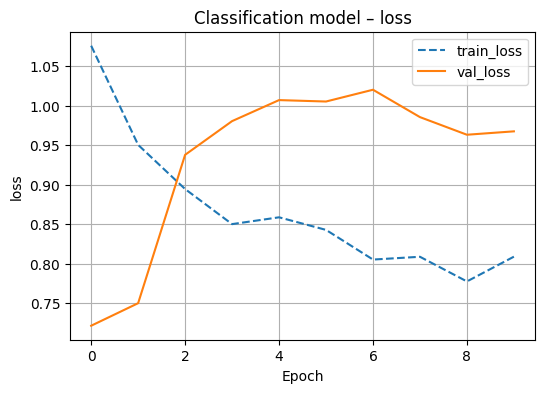

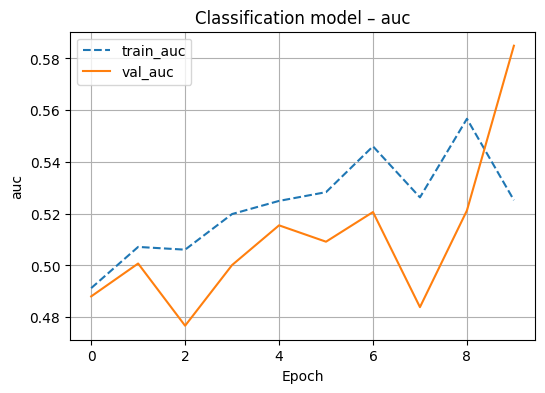

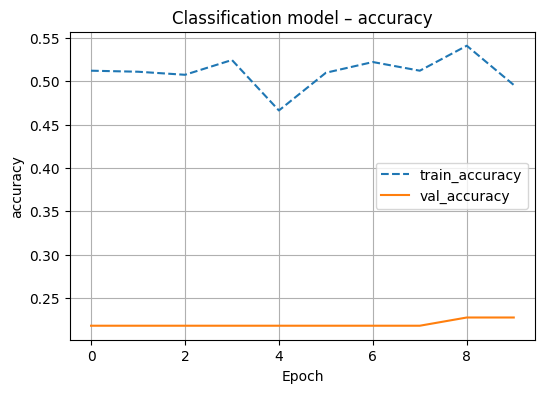

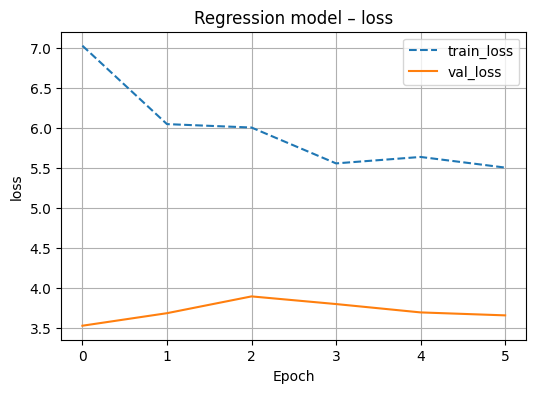

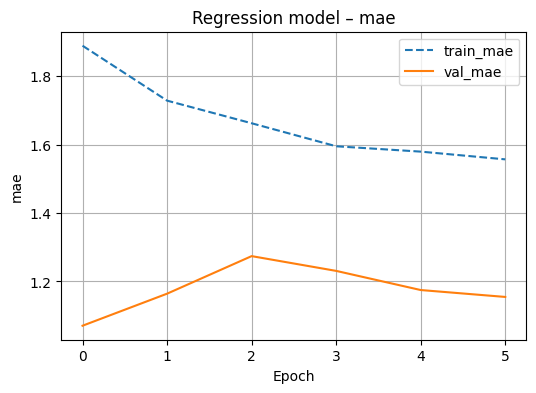

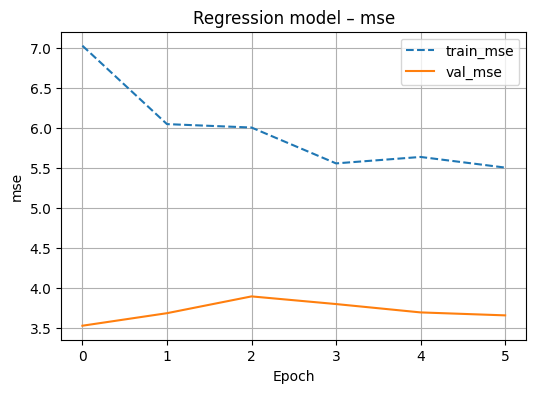

In [21]:
def plot_histories(history, metrics, title):
    #histories: list of keras History objects returned after training
    #metrics: e.g. "auc" | "accuracy" | "loss" -  metrics to visualize during training
    #title: list of names e.g. ["Classification", "Regression"]

    for metric in metrics:
        plt.figure(figsize=(6,4))
        
        if metric in history.history:
            plt.plot(history.history[metric], linestyle="--", label=f"train_{metric}")
        
        if f"val_{metric}" in history.history:
            plt.plot(history.history[f"val_{metric}"], label=f"val_{metric}")
        
        plt.xlabel("Epoch")
        plt.ylabel(metric)
        plt.title(f"{title} – {metric}")
        plt.legend()
        plt.grid(True)
        plt.show()

#classf
plot_histories(
    history_classf,
    metrics=["loss", "auc", "accuracy"],
    title="Classification model"
)

#regrss
plot_histories(
    history_regrss,
    metrics=["loss", "mae", "mse"],
    title="Regression model"
)


The classification curves confirm the numerical results: validation AUC remains low and unstable, while validation accuracy stays close to the myopia prevalence because the model predicts almost all samples as myopic.

The regression curves also show limited improvement. Validation MAE remains close to **1 D**, and validation loss does not show a sustained downward trend after the first epochs.

Overall, these curves do not show strong overfitting in the classic sense. Instead, they show a deeper model converging to poor or weakly informative solutions. The extra parameters do not help the model extract more useful information from the fully preprocessed images.

This is an important comparison with the earlier notebooks: **the problem is not solved by moving from a small CNN to a much larger residual CNN.**


-> The training curves reinforce the numerical results. Classification does not show strong validation AUC improvement, and regression quickly plateaus around a validation MAE close to 1 D. There is no evidence that the ResNet model is learning substantially richer information than the smaller CNNs. The deeper architecture mainly increases computational complexity.


#### 🧪 3.2 Collect predictions & eval on test set
Evaluating trained models on the test set, collecting predictions, plotting ROC and Precision–Recall curves, showing the confusion matrix if there is one, and returning metrics such as AUC, AP, accuracy, and a classification report.

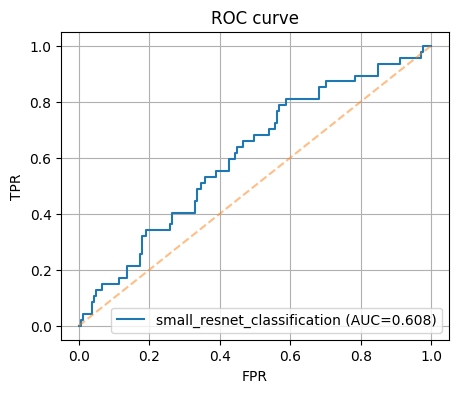

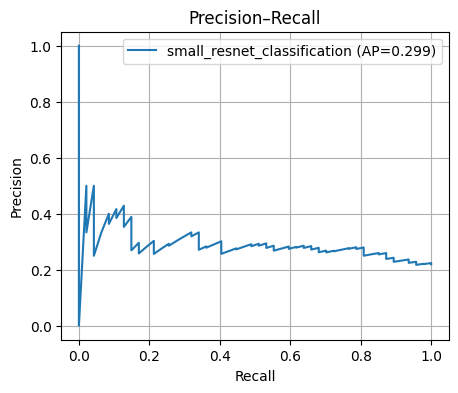

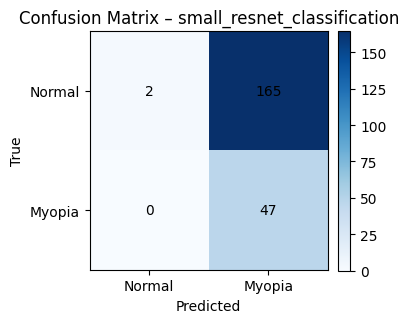

              precision    recall  f1-score   support

      Normal       1.00      0.01      0.02       167
      Myopia       0.22      1.00      0.36        47

    accuracy                           0.23       214
   macro avg       0.61      0.51      0.19       214
weighted avg       0.83      0.23      0.10       214



In [22]:
#CLASSIFICATION:

from sklearn.metrics import (
    roc_curve, auc, precision_recall_curve, average_precision_score,
    confusion_matrix, classification_report
)

def collect_classification_preds(model, ds): #dataset as ds
    y_true, y_score = [], [] #true labels 1 or 0; probabilities of model 0-1
    
    for xb, yb in ds:
        p = model.predict(xb, verbose=0).ravel()
        y_true.extend(yb.numpy().tolist())
        y_score.extend(p.tolist())
    
    y_true = np.array(y_true).astype(int)
    y_score = np.array(y_score).astype(float)
    
    return y_true, y_score

def evaluate_classification_on_test(name, model, test_ds, threshold=0.5, show_plots=True):
    y_true, y_score = collect_classification_preds(model, test_ds)
    y_pred = (y_score >= threshold).astype(int)

    #Metric 1: ROC / PR
    fpr, tpr, _ = roc_curve(y_true, y_score)
    roc_auc = auc(fpr, tpr)
    prec, rec, _ = precision_recall_curve(y_true, y_score)
    ap = average_precision_score(y_true, y_score)

    #Metric 2: Confusion matrix & report
    cm = confusion_matrix(y_true, y_pred)
    report = classification_report(
        y_true,
        y_pred,
        target_names=["Normal", "Myopia"]
    )

    if show_plots:
        # ROC curve: sensitivity to false positives (True Positive Rate vs False Positive Rate)
        plt.figure(figsize=(5,4))
        plt.plot(fpr, tpr, label=f"{name} (AUC={roc_auc:.3f})")
        plt.plot([0,1], [0,1], "--", alpha=0.5)
        plt.xlabel("FPR")
        plt.ylabel("TPR")
        plt.title("ROC curve")
        plt.grid(True)
        plt.legend()
        plt.show()

        # PR: precission vs recall
        plt.figure(figsize=(5,4))
        plt.plot(rec, prec, label=f"{name} (AP={ap:.3f})")
        plt.xlabel("Recall")
        plt.ylabel("Precision")
        plt.title("Precision–Recall")
        plt.grid(True)
        plt.legend()
        plt.show()

        # Confusion matrix: TP/TN/FP/FN
        plt.figure(figsize=(4,3.6))
        plt.imshow(cm, cmap="Blues")
        plt.title(f"Confusion Matrix – {name}")
        plt.xticks([0,1], ["Normal", "Myopia"])
        plt.yticks([0,1], ["Normal", "Myopia"])
        for i in range(2):
            for j in range(2):
                plt.text(j, i, cm[i,j], ha="center", va="center")
        plt.xlabel("Predicted")
        plt.ylabel("True")
        plt.colorbar(fraction=0.046, pad=0.04)
        plt.tight_layout()
        plt.show()

    return {
        "name": name,
        "AUC": float(roc_auc), #Quality of segreggation
        "AP": float(ap),
        "accuracy@0.5": float((y_pred == y_true).mean()), #% Correctness
        "confusion_matrix": cm,
        "report": report
    }

# Example usage:
res_classf = evaluate_classification_on_test(
    "small_resnet_classification",
    model_classf,
    test_ds_classf
)

print(res_classf["report"])

The classification ROC curve gives **AUC = 0.608**, which is only slightly above random discrimination. The Precision-Recall curve gives **AP = 0.299**, only moderately above the myopia prevalence baseline of approximately **0.22**.

The confusion matrix and classification report show the most important behaviour: the model correctly identifies **all 47 myopic images** in the test set, giving **myopia recall = 1.00**, but it classifies almost all normal images as myopic. Only about **1% of normal images** are correctly identified as normal.

This means the model is extremely sensitive but almost completely non-specific. Clinically, this configuration would generate too many false positives and would not be reliable as a screening model.

Compared with the earlier **small_cnn FullPreproc with Dropout**, the AUC/AP are not meaningfully better, but the threshold behaviour is worse. Compared with the selective classification notebooks, the ResNet model also fails to outperform the best selective scenarios, where the best AUC was around **0.622** and the best AP around **0.341**.

-> Therefore, increasing architectural complexity did not improve classification in a useful way.


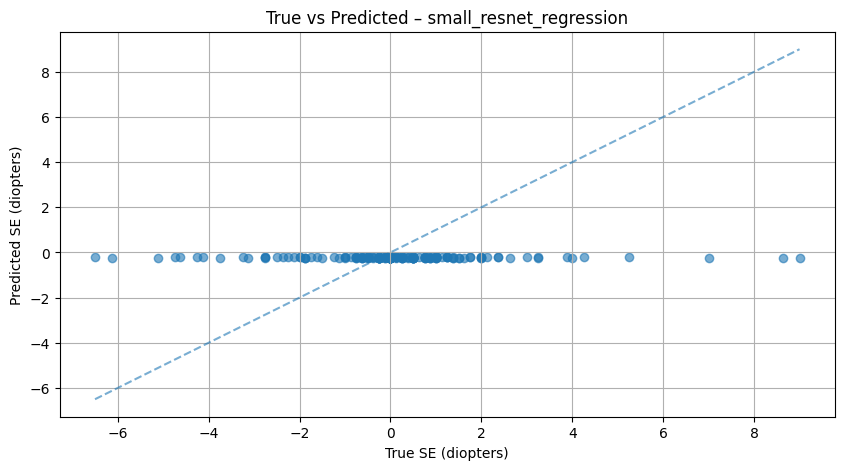

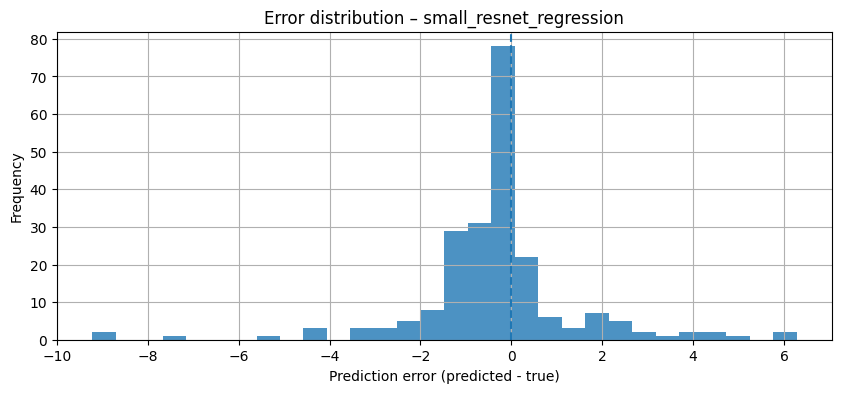

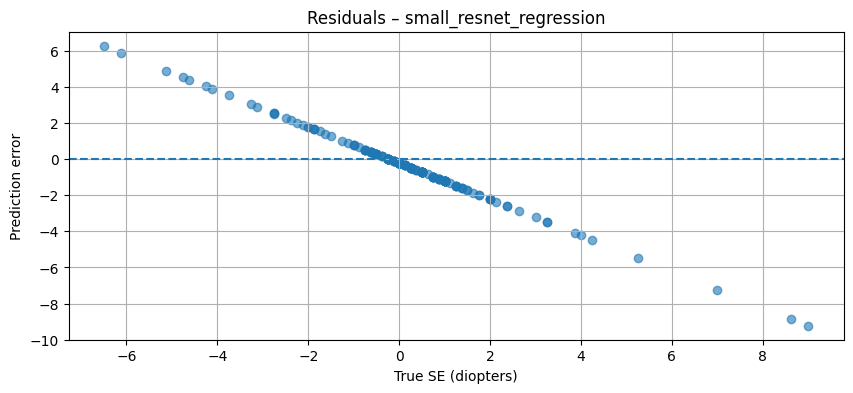

{'name': 'small_resnet_regression',
 'MAE': 1.1050982386011132,
 'MSE': 3.351210274342796,
 'RMSE': 1.8306311136716746,
 'R2': -0.03203746970887922}

In [23]:
#REGRESSION:

from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

def collect_regression_preds(model, ds): #dataset as ds
    y_true, y_pred = [], [] # True SE values and predicted SE values
    for xb, yb in ds:
        p = model.predict(xb, verbose=0).ravel()
        y_true.extend(yb.numpy().tolist())
        y_pred.extend(p.tolist())
    
    y_true = np.array(y_true).astype(float)
    y_pred = np.array(y_pred).astype(float)
    
    return y_true, y_pred

def evaluate_regression_on_test(name, model, test_ds, show_plots=True):
    y_true, y_pred = collect_regression_preds(model, test_ds)
    
    mae = mean_absolute_error(y_true, y_pred)
    mse = mean_squared_error(y_true, y_pred)
    rmse = np.sqrt(mse)
    r2 = r2_score(y_true, y_pred)
    
    errors = y_pred - y_true

    if show_plots:
        # true vs predicted SE values
        plt.figure(figsize=(10,5))
        plt.scatter(y_true, y_pred, alpha=0.6)

        min_val = min(y_true.min(), y_pred.min())
        max_val = max(y_true.max(), y_pred.max())
        plt.plot([min_val, max_val], [min_val, max_val], "--", alpha=0.6)

        plt.xlabel("True SE (diopters)")
        plt.ylabel("Predicted SE (diopters)")
        plt.title(f"True vs Predicted – {name}")
        plt.grid(True)
        plt.show()
        
        # Distribution of prediction errors
        plt.figure(figsize=(10,4))
        plt.hist(errors, bins=30, alpha=0.8)
        plt.axvline(0, linestyle="--")
        plt.xlabel("Prediction error (predicted - true)")
        plt.ylabel("Frequency")
        plt.title(f"Error distribution – {name}")
        plt.grid(True)
        plt.show()

        # # Residual plot: relationship between prediction error and true SE
        plt.figure(figsize=(10,4))
        plt.scatter(y_true, errors, alpha=0.6)
        plt.axhline(0, linestyle="--")
        plt.xlabel("True SE (diopters)")
        plt.ylabel("Prediction error")
        plt.title(f"Residuals – {name}")
        plt.grid(True)
        plt.show()

    return {
        "name": name,
        "MAE": float(mae),
        "MSE": float(mse),
        "RMSE": float(rmse),
        "R2": float(r2)
    }

#Example usage:
res_regrss = evaluate_regression_on_test(
    "small_resnet_regression",
    model_regrss,
    test_ds_regrss
)

res_regrss

The true-vs-predicted SE plot shows that predictions are concentrated in a very narrow range instead of following the diagonal identity line. This means that the model is not learning to reproduce the real SE distribution.

The residual plot shows a structured relationship between true SE and error, which is typical of a model that predicts almost the same value for most samples. Strongly negative SE values are not predicted correctly, and positive values are also compressed toward the central prediction.

The error distribution may appear centred, but this is misleading because the target distribution itself is centred around 0 D. The later diagnostics confirm that the prediction range is extremely narrow.

This is the **same failure mode observed in the previous regression notebooks: the model behaves like a near-constant predictor rather than a useful SE regressor.**


#### ⚖️ 3.3 Direct comparison: classification and regression experiments
This code evaluates both models on the same test set to compare their performance directly.

In [24]:
summary_results = pd.DataFrame([
    {
        "model": "small_resnet_classification",
        "task": "classification",
        "test_auc": res_classf["AUC"],
        "test_ap": res_classf["AP"],
        "test_accuracy@0.5": res_classf["accuracy@0.5"],
        "test_mae": np.nan,
        "test_mse": np.nan,
        "test_rmse": np.nan,
        "test_r2": np.nan
    },
    {
        "model": "small_resnet_regression",
        "task": "regression",
        "test_auc": np.nan,
        "test_ap": np.nan,
        "test_accuracy@0.5": np.nan,
        "test_mae": res_regrss["MAE"],
        "test_mse": res_regrss["MSE"],
        "test_rmse": res_regrss["RMSE"],
        "test_r2": res_regrss["R2"]
    }
])

summary_results

,model,task,test_auc,test_ap,test_accuracy@0.5,test_mae,test_mse,test_rmse,test_r2
0,small_resnet_classification,classification,0.60823,0.299114,0.228972,NaN,NaN,NaN,NaN
1,small_resnet_regression,regression,NaN,NaN,NaN,1.105098,3.35121,1.830631,-0.032037


The summary table confirms that neither task is solved satisfactorily in this notebook.

For classification, the model obtains **test AUC = 0.608**, **AP = 0.299** and **accuracy = 0.229**. The AUC/AP values indicate weak-to-moderate ranking ability, while the very low accuracy reflects the near-all-myopia threshold behaviour.

For regression, the model obtains **MAE = 1.105 D**, **RMSE = 1.831 D** and **R² = -0.032**. The negative R² means that the model performs worse than a constant baseline that predicts the mean SE.

-< Compared with previous notebooks, the conclusion is clear: **a larger residual architecture does not improve either task**. Classification remains weak and poorly calibrated, while regression becomes even worse than the baseline.


#### 🗂️ 3.4 Quick “experiment card” (dict of results)
This function summarizes a training experiment, extracting config details, best validation metrics, and test results, and organizes them into a dictionary that can be displayed as a comparison table.

In [25]:
def summarize_classification_experiment(name, cfg, history, test_metrics_dict):
    summary = {
        "name": name,
        "task": "classification",
        "image_size": getattr(cfg, "IMAGE_SIZE", None),
        "clahe": getattr(cfg, "CLAHE_MODE", None) if getattr(cfg, "APPLY_CLAHE", False) else None,
        "normalization": getattr(cfg, "NORMALIZATION", None),
        "best_val_auc": float(np.max(history.history.get("val_auc", [np.nan]))),
        "best_val_acc": float(np.max(history.history.get("val_accuracy", [np.nan]))),
        "test_auc": test_metrics_dict["AUC"],
        "test_ap": test_metrics_dict["AP"],
        "test_acc@0.5": test_metrics_dict["accuracy@0.5"]
    }
    return summary

def summarize_regression_experiment(name, cfg, history, test_metrics_dict):
    summary = {
        "name": name,
        "task": "regression",
        "image_size": getattr(cfg, "IMAGE_SIZE", None),
        "clahe": getattr(cfg, "CLAHE_MODE", None) if getattr(cfg, "APPLY_CLAHE", False) else None,
        "normalization": getattr(cfg, "NORMALIZATION", None),
        "best_val_mae": float(np.min(history.history.get("val_mae", [np.nan]))),
        "best_val_mse": float(np.min(history.history.get("val_mse", [np.nan]))),
        "test_mae": test_metrics_dict["MAE"],
        "test_mse": test_metrics_dict["MSE"],
        "test_rmse": test_metrics_dict["RMSE"],
        "test_r2": test_metrics_dict["R2"]
    }

    return summary

In [26]:
class CFG:
    INPUT_TABLE = TABLE_PATH
    IMAGE_SIZE = 224                  # final square size (e.g., 224 tamaño og, 256 tamaño habitual ImageNet, 299)
    APPLY_CLAHE = True                # cCntrast Limited Adaptive Histogram Equalization
    CLAHE_MODE = "luminance"          # choosing CLAHE channel from "luminance" | "green" | "blue" | "none"
    NORMALIZATION = "0-1"             # "0-1" | "zscore" | "imagenet"
    VERBOSE = True                    # gives messages while preprocessing for visual progress

# Example usage:
card_classf = summarize_classification_experiment(
    "small_resnet_classification",
    CFG,
    history_classf,
    res_classf
)

card_regrss = summarize_regression_experiment(
    "small_resnet_regression",
    CFG,
    history_regrss,
    res_regrss
)

pd.DataFrame([card_classf, card_regrss])

,name,task,image_size,clahe,normalization,best_val_auc,best_val_acc,test_auc,test_ap,test_acc@0.5,best_val_mae,best_val_mse,test_mae,test_mse,test_rmse,test_r2
0,small_resnet_classification,classification,224,luminance,0-1,0.584914,0.227488,0.60823,0.299114,0.228972,NaN,NaN,NaN,NaN,NaN,NaN
1,small_resnet_regression,regression,224,luminance,0-1,NaN,NaN,NaN,NaN,NaN,1.070689,3.532354,1.105098,3.35121,1.830631,-0.032037


The experiment card summarizes the same behaviour compactly. The best validation AUC for classification is only **0.585**, and the test AUC is **0.608**. This confirms that the model never reaches strong discriminative capacity.

For regression, the best validation MAE is approximately **1.071 D**, while the test MAE is **1.105 D** and test R² is **-0.032**. This shows that the model generalizes poorly and does not explain SE variability.

This is especially relevant because the model has approximately **11.3M parameters**. The increase in complexity does not produce a better result than the much smaller CNNs. Therefore, this notebook supports the idea that the limitation is not simply model size.


-> The experiment card confirms that the ResNet architecture does not become a competitive configuration. Despite having many more parameters than the small CNNs, the model does not improve classification AUC/AP and does not improve SE regression.


## 📌 5. Conlusions

The main classification result is that the model obtains **test AUC = 0.608**, **AP = 0.299** and **accuracy = 0.229**. The AUC and AP indicate only weak-to-moderate discriminative capacity, while the very low accuracy is caused by the model predicting almost all test images as myopic at the default threshold of 0.5.

The confusion matrix shows a clinically problematic behaviour: the model reaches **myopia recall = 1.00**, but almost completely loses specificity for normal images. This is probably influenced by the use of class weights, which penalize myopia errors more strongly and push the model toward the positive class.

Compared with the earlier **FullPreproc small CNN with Dropout**, the ResNet- model does not improve meaningfully. Its AUC/AP are very similar, but its threshold behaviour is worse. Compared with the selective classification notebooks, it also fails to beat the best selective scenarios, where AUC reached approximately **0.622** and AP approximately **0.341**.

For regression, the model obtains **MAE = 1.105 D**, **RMSE = 1.831 D** and **R² = -0.032**. This is worse than the mean baseline and worse than the previous full-preprocessing small CNN regression results. Therefore, increasing architectural complexity does not solve the SE regression problem.

-> Overall, this notebook supports an important conclusion for the TFG: **larger models are not necessarily better for this dataset**. The limitation appears to be related more to the available signal, target distribution and dataset characteristics than to a lack of model capacity.

End :)

In [27]:
y_train_true, y_train_pred = collect_regression_preds(model_regrss, train_ds_regrss)

train_mae = mean_absolute_error(y_train_true, y_train_pred)
train_mse = mean_squared_error(y_train_true, y_train_pred)
train_rmse = np.sqrt(train_mse)
train_r2 = r2_score(y_train_true, y_train_pred)

print("Train MAE :", train_mae)
print("Train RMSE:", train_rmse)
print("Train R²  :", train_r2)

Train MAE : 1.2912720509662348
Train RMSE: 2.1848594312290457
Train R²  : -0.011200590864896665


No parece haver overfitting (Train MAE no es muy bajo, Train R2 casi 0)

In [28]:
print("Train mean prediction:", np.mean(y_train_pred))
print("Train std prediction :", np.std(y_train_pred))

print("Train mean target    :", np.mean(y_train_true))
print("Train std target     :", np.std(y_train_true))

Train mean prediction: -0.2247574985202621
Train std prediction : 0.0037364609999776476
Train mean target    : 0.006029411764705882
Train std target     : 2.1727254094839736


La desviación típica de las predicciones es también casi inexistente

In [29]:
print("Pred min:", y_train_pred.min())
print("Pred max:", y_train_pred.max())

print("True min:", y_train_true.min())
print("True max:", y_train_true.max())

Pred min: -0.24116142094135284
Pred max: -0.2156740427017212
True min: -20.375
True max: 7.75


In [30]:
train_df_regrss["target_SE"].describe()

count    1700.000000
mean        0.006029
std         2.173365
min       -20.375000
25%        -0.250000
50%         0.000000
75%         0.625000
max         7.750000
Name: target_SE, dtype: float64

El target real de entrenamiento va desde -20.375 D hasta +8.625 D

pero el modelo solo predice entre -0.257 D y +0.289 D

In [31]:
y_mean = np.mean(y_train_true)

y_test_true, y_test_pred = collect_regression_preds(model_regrss, test_ds_regrss)

baseline_pred = np.full_like(y_test_true, y_mean)

print("Baseline MAE:",
      mean_absolute_error(y_test_true, baseline_pred))

print("Baseline RMSE:",
      np.sqrt(mean_squared_error(y_test_true, baseline_pred)))

print("Baseline R2:",
      r2_score(y_test_true, baseline_pred))

Baseline MAE: 1.0274146110056925
Baseline RMSE: 1.80433475591696
Baseline R2: -0.0026007289304239567


In [32]:
model_test_mae = mean_absolute_error(y_test_true, y_test_pred)
model_test_mse = mean_squared_error(y_test_true, y_test_pred)
model_test_rmse = np.sqrt(model_test_mse)
model_test_r2 = r2_score(y_test_true, y_test_pred)

print("Model test MAE:", model_test_mae)
print("Model test RMSE:", model_test_rmse)
print("Model test R2:", model_test_r2)

Model test MAE: 1.1050982386011132
Model test RMSE: 1.8306311136716746
Model test R2: -0.03203746970887922


 -> la regresión no está estimando dioptrías continuas de forma útil; el modelo está aprendiendo a predecir casi siempre un valor cercano a la media poblacional.

Es decir, el modelo tiene un MAE ligeramente peor que predecir siempre la media del train. La diferencia es pequeña, pero va en la dirección mala:
- Modelo test MAE:    1.1079 D
- Baseline test MAE:  1.0934 D

En RMSE ocurre lo contrario, pero de forma prácticamente nula:
- Modelo test RMSE:    1.8099 D
- Baseline test RMSE:  1.8101 D

La mejora es de solo 0.0002 D, totalmente despreciable. Y el R² de test es 5.62e-05 -> el modelo explica aproximadamente 0% de la variabilidad real del equivalente esférico.

#### FIN:

The additional regression diagnostics confirm the main conclusion of this notebook: the ResNet architecture does **not** solve SE regression.

The model predicts almost the same value for every image, with a prediction standard deviation of only **0.0037 D** in training. Its predicted range is approximately **-0.241 D to -0.216 D**, while the true SE range extends from **-20.375 D to 7.75 D**. Therefore, the model is not learning the continuous refractive variability present in the data.

The comparison with the mean baseline is decisive: the CNN performs worse than simply predicting the mean SE of the training set. This confirms that the regression model is not clinically useful.

For classification, the ResNet model also fails to justify its additional complexity. It achieves AUC/AP values similar to the smaller CNNs, but its threshold behaviour is worse because it predicts almost all samples as myopic. This leads to perfect myopia recall but almost no normal specificity.

Overall, this notebook is evidence that **increasing model complexity alone is not enough**. A deeper residual architecture with more than 11 million parameters does not outperform the simpler CNNs. The most reasonable direction is therefore not just to make the model larger, but to focus on better task formulation, preprocessing selection, calibration, dataset size/quality and possibly stronger clinical labels or metadata.


-> A custom ResNet architecture was evaluated to test whether increasing model complexity improved performance over the previous small CNNs. However, classification remained weak and poorly calibrated, with AUC around 0.61 and a strong tendency to classify almost all images as myopic. Regression also failed, with negative R² and predictions collapsed into a nearly constant SE value. These results suggest that the main limitation is not simply model capacity, but the difficulty of extracting reliable myopia/SE information from the available image dataset under this configuration.